In [17]:
import dadi, dadi.Polyploidy, dadi.DFE
import numpy as np
import matplotlib.pyplot as plt


In [18]:
# first, calculate B-value
syn = dadi.Spectrum.from_file('syn.sfs')
sim_pi_auto = syn.marginalize([0]).pi()
sim_pi_dip = syn.marginalize([1]).pi()

# then, the model
model = dadi.Polyploidy.auto_demographics.bottlegrowth_dip_size_change_asym_mig
model_ex = dadi.Numerics.make_extrap_func(model)
ns = syn.sample_sizes
pts_l = [151, 161, 171]
p_true = [0.15, 0.15, 0.3, 0.7, 0.8, 0.0, 2.0]
theta_true = 4 * 7e-9/3.5 * 5e6 * 161774
model_sfs = theta_true * model_ex(p_true, ns, pts_l)
model_pi_auto = model_sfs.marginalize([0]).pi()
model_pi_dip = model_sfs.marginalize([1]).pi()

# then, the B-value
print(f"B-value (auto): {sim_pi_auto/model_pi_auto}")
print(f"B-value (dip): {sim_pi_dip/model_pi_dip}")



B-value (auto): 0.9039163964057447
B-value (dip): 0.8901907187606547


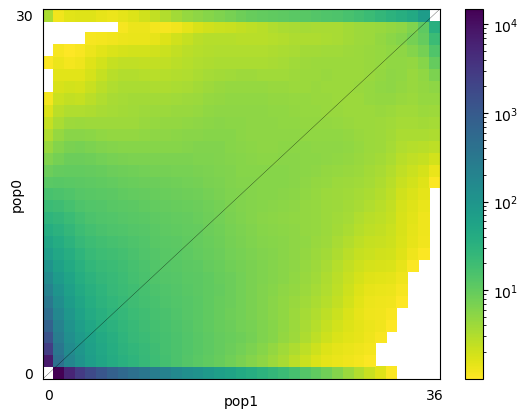

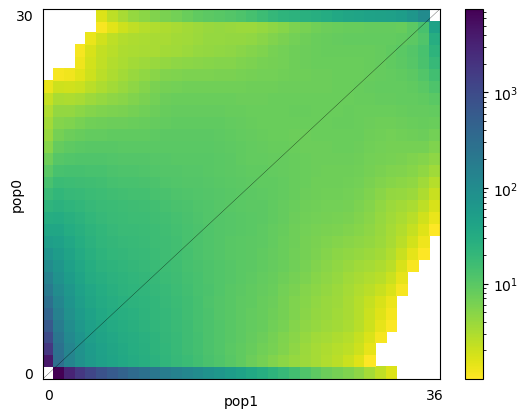

In [19]:
# load the data
nonsyn = dadi.Spectrum.from_file('nonsyn.sfs')
syn = dadi.Spectrum.from_file('syn.sfs')

# down project and plot
nonsyn_dp = nonsyn.project([30,36])
syn_dp = syn.project([30,36])
nonsyn_dp.mask[np.where(nonsyn_dp.data < 1)] = True
syn_dp.mask[np.where(syn_dp.data < 1)] = True
dadi.Plotting.plot_single_2d_sfs(nonsyn_dp)
dadi.Plotting.plot_single_2d_sfs(syn_dp)


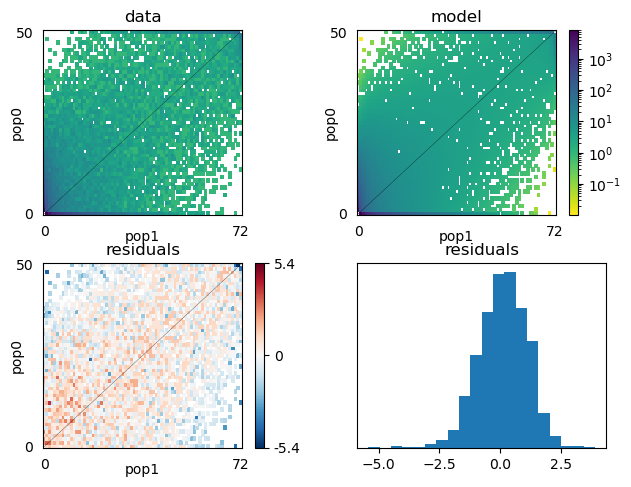

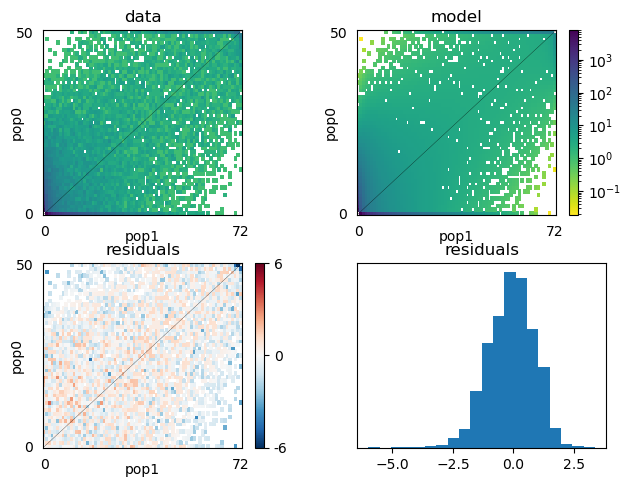

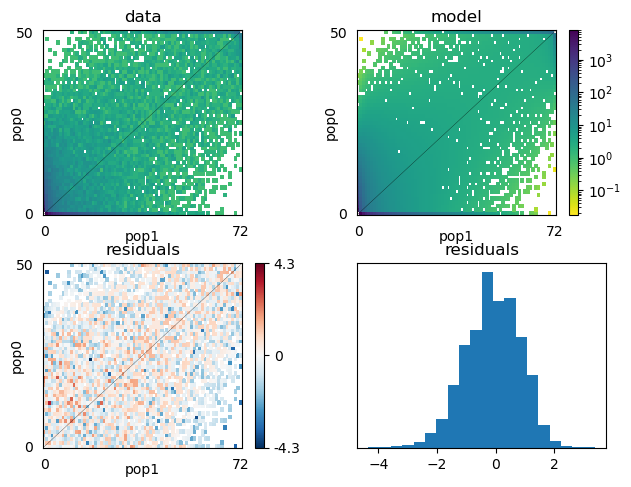

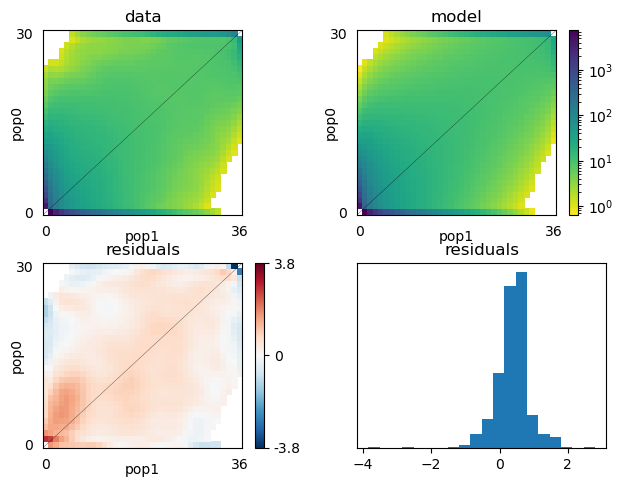

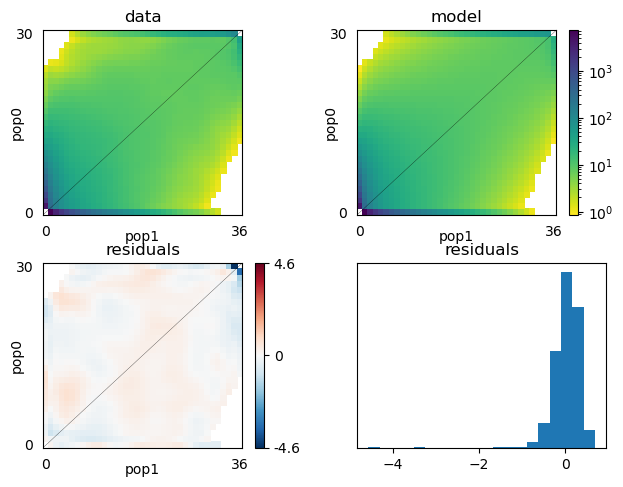

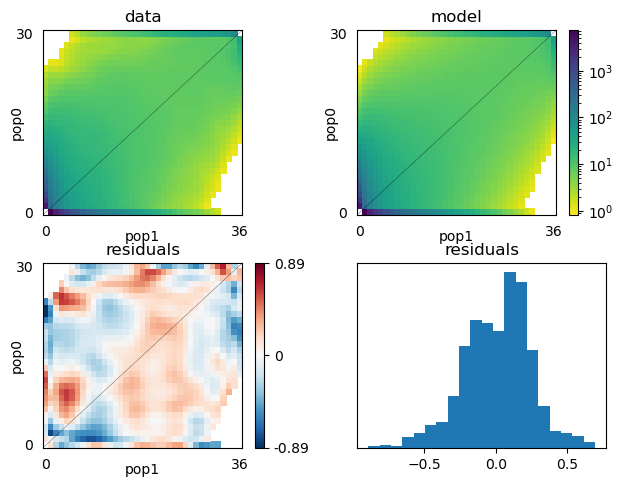

In [20]:
p_best = [0.10016056968594887, 0.22253176468847155, 0.33086271533482525, 
          0.7860278669066451, 0.8587950518272727, 0.0, 1.6271020740643924]
theta_best = 5829.186425046863

p_best_misid = [0.15643453295170537, 0.18016569336579513, 0.33479625706566585, 0.8027038409573716, 
                0.8769240598698516, 0.0, 1.6088514244882333, 0.005176140041246104]
theta_best_misid = 5725.876533095068

p_true = [0.15, 0.15, 0.3, 0.7, 0.8, 0.0, 2.0]
theta_true = 4 * 7e-9/3.5 * 5e6 * 161744

model = dadi.Polyploidy.auto_demographics.bottlegrowth_dip_size_change_asym_mig
model_ex = dadi.Numerics.make_extrap_func(model)
ns = syn.sample_sizes
pts_l = [max(ns)+101, max(ns)+111, max(ns)+121]

model_misid = dadi.Numerics.make_anc_state_misid_func(model)
model_misid_ex = dadi.Numerics.make_extrap_func(model_misid)

syn_model = theta_best * model_ex(p_best, ns, pts_l)

syn.mask[np.where(syn.data == 0)] = True

syn_model_true = theta_true * model_ex(p_true, ns, pts_l)
dadi.Plotting.plot_2d_comp_Poisson(syn_model_true, syn)

dadi.Plotting.plot_2d_comp_Poisson(syn_model, syn)

syn_model_misid = theta_best_misid * model_misid_ex(p_best_misid, ns, pts_l)
dadi.Plotting.plot_2d_comp_Poisson(syn_model_misid, syn)


ns = syn_dp.sample_sizes
pts_l = [max(ns)+101, max(ns)+111, max(ns)+121]
# also compare the to the down-projected data
syn_model_true_dp = theta_true * model_ex(p_true, ns, pts_l)
dadi.Plotting.plot_2d_comp_Poisson(syn_model_true_dp, syn_dp)

syn_model_dp = theta_best * model_ex(p_best, ns, pts_l)
dadi.Plotting.plot_2d_comp_Poisson(syn_model_dp, syn_dp)

syn_model_misid_dp = theta_best_misid * model_misid_ex(p_best_misid, ns, pts_l)
dadi.Plotting.plot_2d_comp_Poisson(syn_model_misid_dp, syn_dp)



True
Best fit w/o misid
Best fit w/ misid


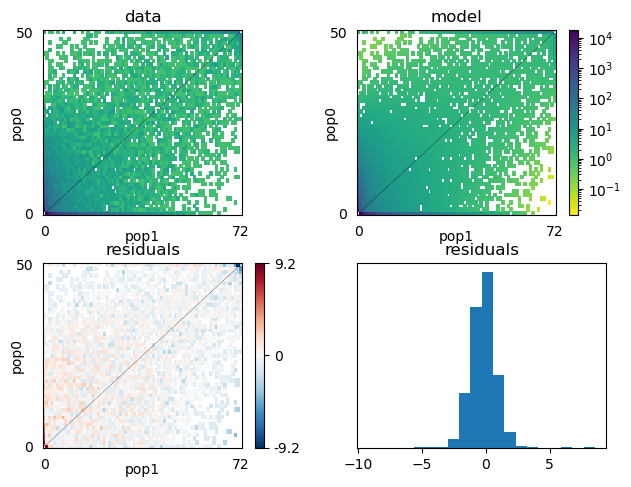

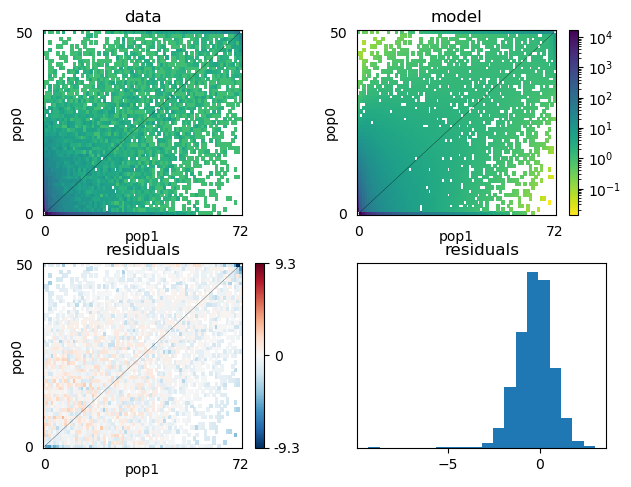

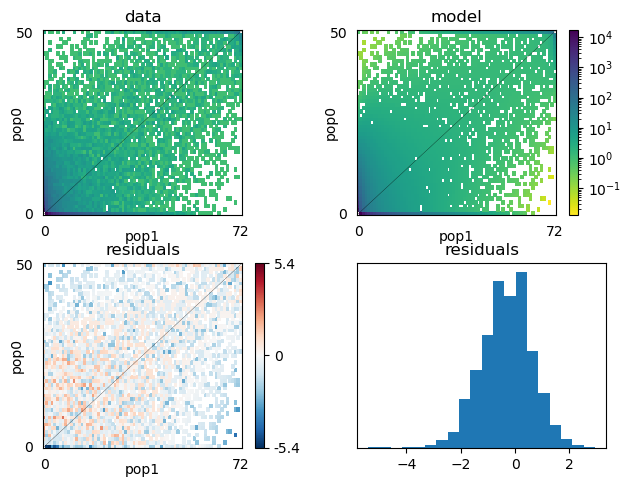

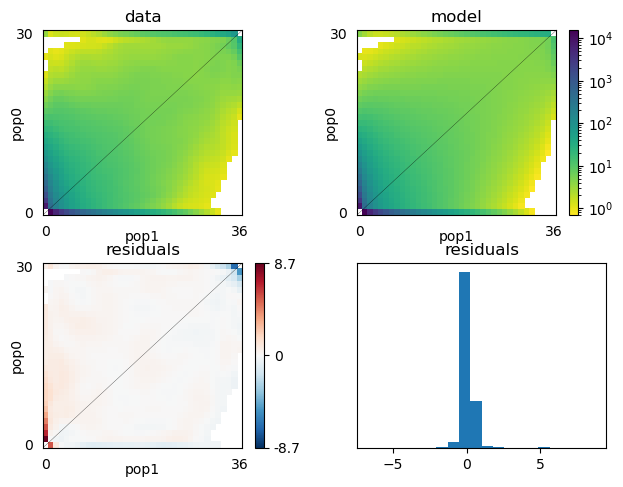

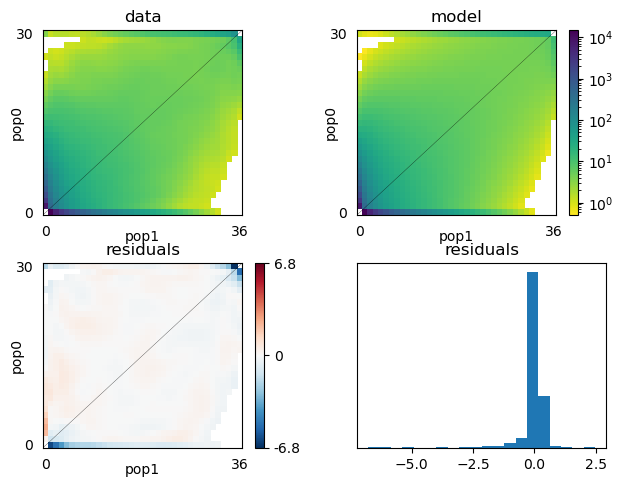

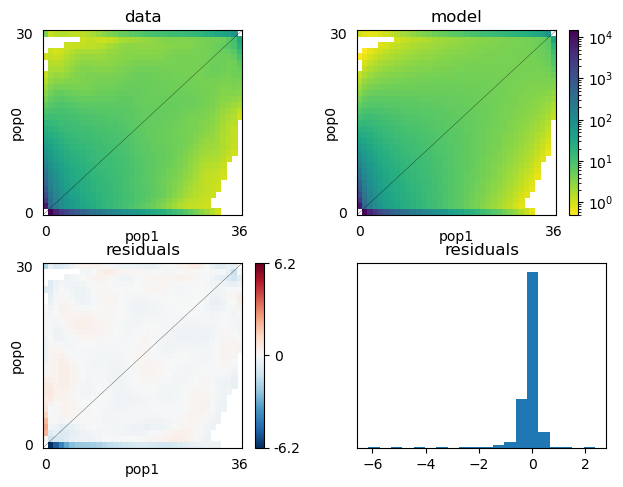

In [21]:
import pickle

cache_1d = pickle.load(open('auto_1d_cache.bpkl', 'rb'))
cache_2d = pickle.load(open('auto_2d_cache.bpkl', 'rb'))

cache_1d_misid = pickle.load(open('auto_misid_1d_cache.bpkl', 'rb'))
cache_2d_misid = pickle.load(open('auto_misid_2d_cache.bpkl', 'rb'))

mixture_DFE = dadi.DFE.mixture

mixture_DFE_misid = dadi.Numerics.make_anc_state_misid_func(mixture_DFE)

lnorm_1d = dadi.DFE.PDFs.lognormal
lnorm_2d = dadi.DFE.PDFs.biv_lognormal

p_best_DFE = [1.4730240862901656, 2.3162218727598702, 0.0, 0.02232456054568833]
theta_best_DFE = 14152.626041372287

p_best_DFE_misid = [1.4683838372539537, 2.265314021973198, 0.0, 0.02534048805225546, 0.0029561298020399068]
theta_best_DFE_misid = 13835.549011491255

p_true_DFE = [1.69155136, 2.37871223, 0.0, 0.075]
theta_true_DFE = 4 * 7e-9 * (2.5/3.5) * 5e6 * 161744

ns = nonsyn.sample_sizes

nonsyn.mask[np.where(nonsyn.data == 0)] = True

print("True")
nonsyn_true = mixture_DFE(p_true_DFE, ns, cache_1d, cache_2d, lnorm_1d, lnorm_2d, theta_true_DFE, None)
print('Best fit w/o misid')
nonsyn_best = mixture_DFE(p_best_DFE, ns, cache_1d, cache_2d, lnorm_1d, lnorm_2d, theta_best_DFE, None)
print('Best fit w/ misid')
nonsyn_best_misid = mixture_DFE_misid(p_best_DFE_misid, ns, cache_1d_misid, cache_2d_misid, lnorm_1d, lnorm_2d, theta_best_DFE_misid, None)

dadi.Plotting.plot_2d_comp_Poisson(nonsyn_true, nonsyn)
dadi.Plotting.plot_2d_comp_Poisson(nonsyn_best, nonsyn)
dadi.Plotting.plot_2d_comp_Poisson(nonsyn_best_misid, nonsyn)

# and the down-projected data
ns_dp = nonsyn_dp.sample_sizes

nonsyn_true_dp = nonsyn_true.project(ns_dp)
nonsyn_best_dp = nonsyn_best.project(ns_dp)
nonsyn_best_misid_dp = nonsyn_best_misid.project(ns_dp)

nonsyn_dp.mask[np.where(nonsyn_dp.data == 0)] = True
dadi.Plotting.plot_2d_comp_Poisson(nonsyn_true_dp, nonsyn_dp)
dadi.Plotting.plot_2d_comp_Poisson(nonsyn_best_dp, nonsyn_dp)
dadi.Plotting.plot_2d_comp_Poisson(nonsyn_best_misid_dp, nonsyn_dp)


In [14]:
# separate from all the above focused on down-projection, 
# we can also try to visualize via marginalization

# reload to avoid masking issues
nonsyn = dadi.Spectrum.from_file('nonsyn.sfs')
syn = dadi.Spectrum.from_file('syn.sfs')

syn_dip = syn.marginalize([1])
syn_auto = syn.marginalize([0])

nonsyn_dip = nonsyn.marginalize([1])
nonsyn_auto = nonsyn.marginalize([0])



Best Fit Model w/o misid


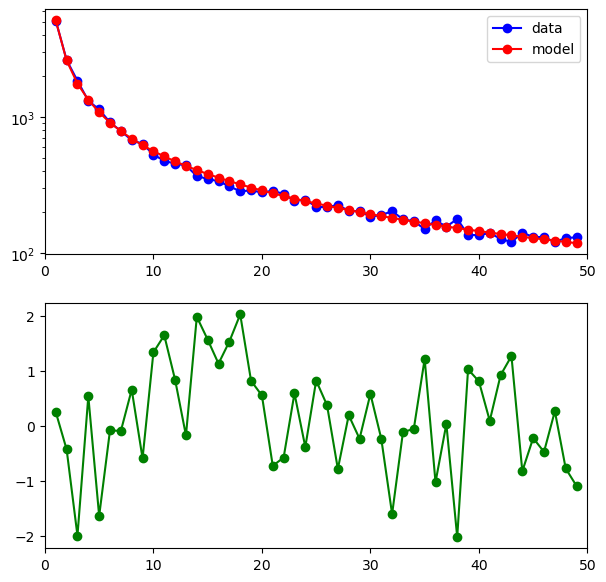

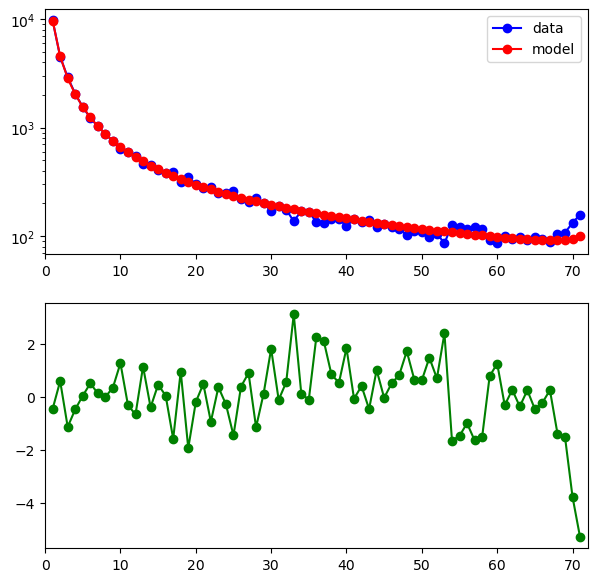

Best Fit Model w/ misid


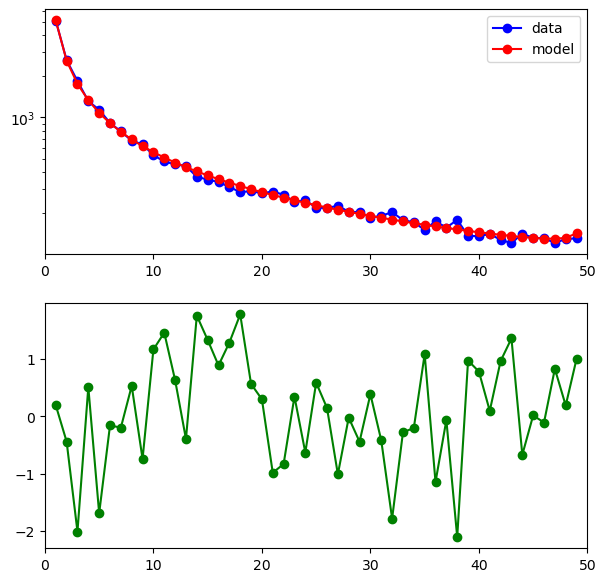

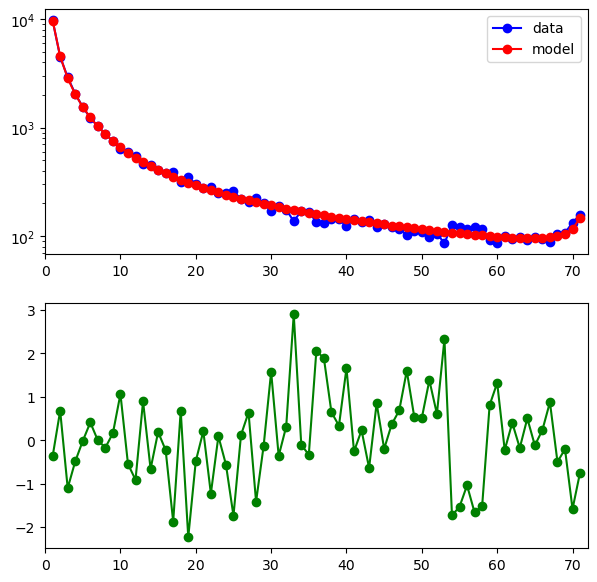

True Model


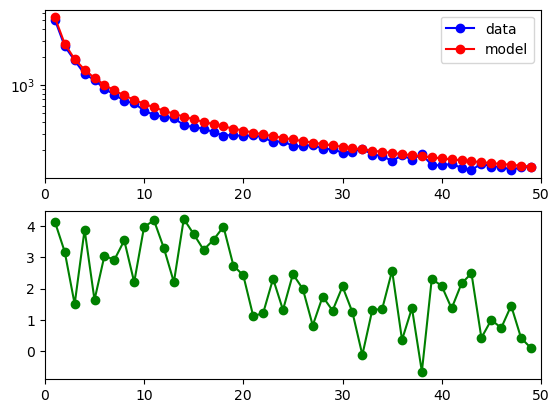

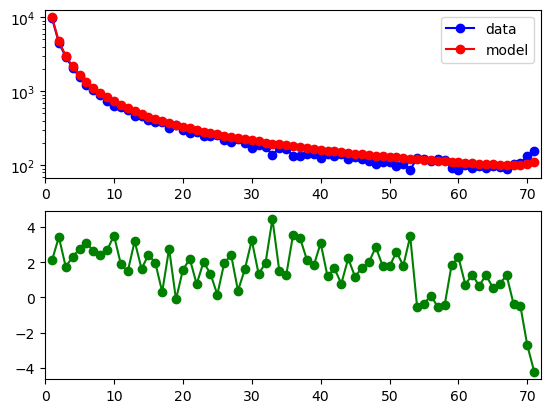

In [15]:
# the synonymous models
syn_dip_model = syn_model.marginalize([1])
syn_auto_model = syn_model.marginalize([0])

syn_dip_true = syn_model_true.marginalize([1])
syn_auto_true = syn_model_true.marginalize([0])

syn_dip_misid = syn_model_misid.marginalize([1])
syn_auto_misid = syn_model_misid.marginalize([0])

# plot
print("Best Fit Model w/o misid")
dadi.Plotting.plot_1d_comp_Poisson(syn_dip_model, syn_dip, fig_num=1000)
dadi.Plotting.plot_1d_comp_Poisson(syn_auto_model, syn_auto, fig_num=1001)

print("Best Fit Model w/ misid")
dadi.Plotting.plot_1d_comp_Poisson(syn_dip_misid, syn_dip, fig_num=1002)
dadi.Plotting.plot_1d_comp_Poisson(syn_auto_misid, syn_auto, fig_num=1003)

print("True Model")
dadi.Plotting.plot_1d_comp_Poisson(syn_dip_true, syn_dip)
dadi.Plotting.plot_1d_comp_Poisson(syn_auto_true, syn_auto)


Best Fit Model w/o misid


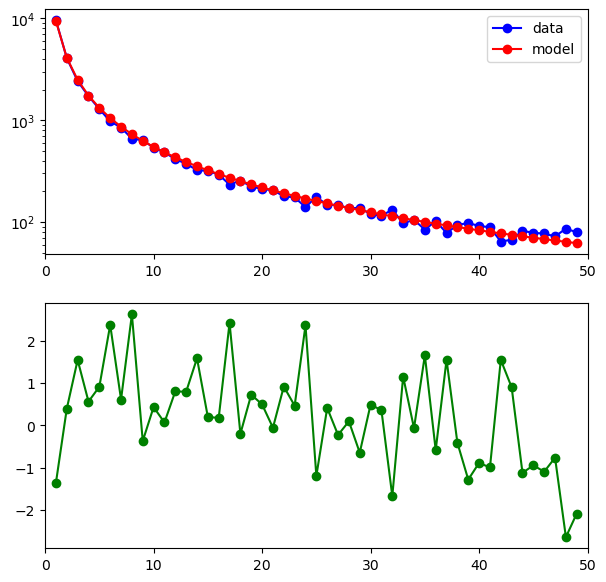

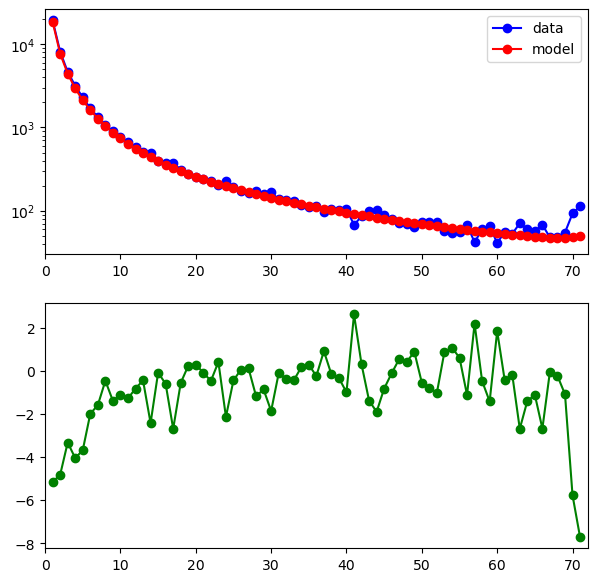

Best Fit Model w/ misid


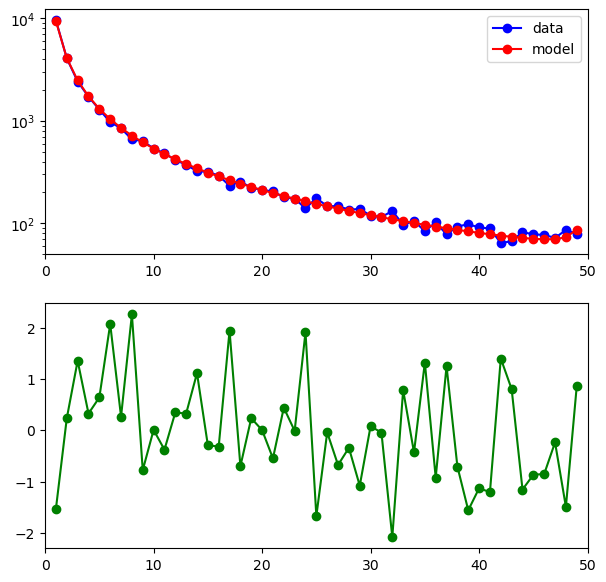

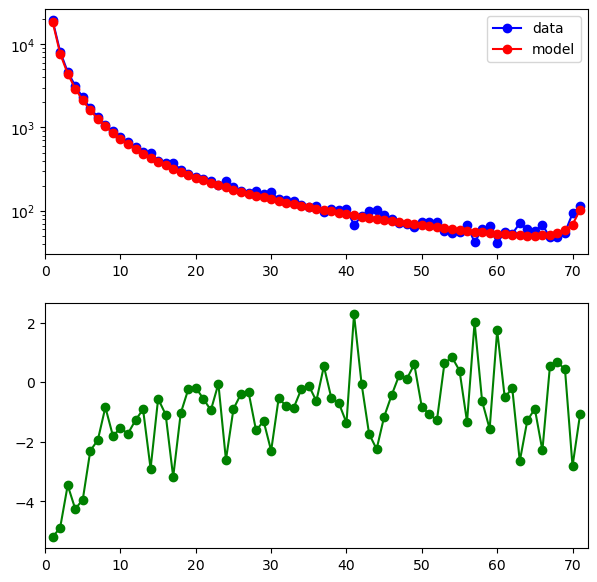

True Model


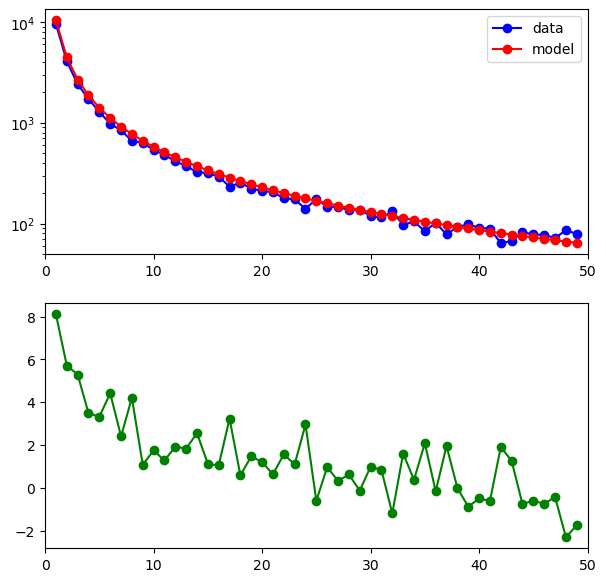

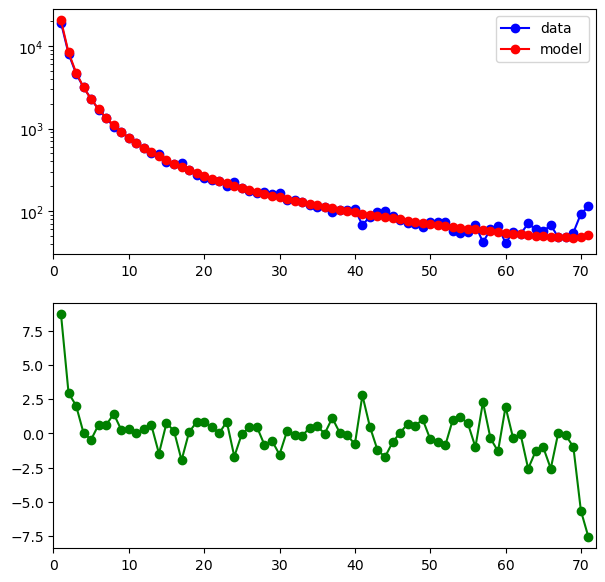

In [16]:
# the nonsynonymous models
nonsyn_dip_model = nonsyn_best.marginalize([1])
nonsyn_auto_model = nonsyn_best.marginalize([0])

nonsyn_dip_misid = nonsyn_best_misid.marginalize([1])
nonsyn_auto_misid = nonsyn_best_misid.marginalize([0])

nonsyn_dip_true = nonsyn_true.marginalize([1])
nonsyn_auto_true = nonsyn_true.marginalize([0])

# plot
print("Best Fit Model w/o misid")
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_dip_model, nonsyn_dip, fig_num=1000)
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_auto_model, nonsyn_auto, fig_num=1001)

print("Best Fit Model w/ misid")
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_dip_misid, nonsyn_dip, fig_num=1002)
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_auto_misid, nonsyn_auto, fig_num=1003)

print("True Model")
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_dip_true, nonsyn_dip, fig_num=1004)
dadi.Plotting.plot_1d_comp_Poisson(nonsyn_auto_true, nonsyn_auto, fig_num=1005)